# SMART Mechanism — Statistical Analysis
## Stiffness-Mediated Antibody Redistribution and Trafficking (SMART)

**Manuscript:** Qiu et al., *Stiffness-Mediated Antibody Redistribution and Trafficking (SMART) by β-Glucan Nanomaterials Potentiates Hepatocellular Carcinoma Immunotherapy*

**Purpose:** Complete, reproducible statistical analysis demonstrating that membrane FcγR redistribution (*F*) is the dominant mediating variable through which nanoparticle stiffness (*E*) controls αPD-L1 antibody uptake (*U*).

---

### Variable Definitions

| Symbol | Variable | Unit | Replicates per condition |
|--------|----------|------|--------------------------|
| *E* | Young's modulus (nanoparticle stiffness) | MPa | 60 AFM force–indentation curves |
| *F* | Membrane FcγR surface residual (rel. Blank) | — | 3 biological replicates |
| *U* | αPD-L1 antibody uptake by Kupffer cells (rel. Blank) | — | 3 biological replicates |

### Dataset

- **Platforms:** NIPAM nanoparticles (5 crosslinking conditions) + β-glucan nanoparticles (10 crosslinking conditions)
- **Pooled *n*:** 15 stiffness conditions spanning E = 1.49–191.84 MPa
- **Exposure variable:** log₁₀(*E*) used throughout regression analyses

### Analysis Pipeline

| Section | Method | Primary output |
|---------|--------|----------------|
| §2 | Data import and descriptive statistics | Summary table |
| §3 | Spearman rank correlation | ρ(*F*, *U*) vs ρ(*E*, *U*) |
| §4 | Partial correlation + variance decomposition | Unique R² contributions |
| §5 | OLS bootstrap mediation analysis | Indirect effect *ab*, proportion mediated |
| §6 | Publication figures | Heatmap, partial regression plots, path diagram |
| §7 | Consolidated parameter report | All estimates to 4 decimal places |

---

**Software:** Python 3.10 · NumPy · SciPy · Pandas · Matplotlib  
**Random seed:** 2025 (all bootstrap procedures, B = 20,000)  
**Execution:** Run cells sequentially §0 → §7

---
## §0 — Environment Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED  = 2025
B_ALL = 20_000   # bootstrap resamples for all procedures

# ── Colour palette (Nature-style, colourblind-accessible) ─────────────────────
C_NIPAM  = '#E64B35'   # red   — NIPAM NPs
C_BGLU   = '#4DBBD5'   # teal  — β-glucan NPs
C_FIT    = '#3C5488'   # navy  — OLS regression line
C_ACCENT = '#00A087'   # green — mediation / indirect effect

# ── Matplotlib publication defaults ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'font.family':       'sans-serif',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon':    False,
    'legend.fontsize':   8,
    'lines.linewidth':   1.5,
})

# ── Formatting helpers ────────────────────────────────────────────────────────
def fmt_p(p):
    """Uniform P-value formatting: scientific notation < 0.0001, else 4 d.p."""
    if   p < 0.0001: return f'{p:.2e}'
    elif p < 0.001:  return f'{p:.4f}'
    else:            return f'{p:.4f}'

def ci4(lo, hi):
    """95% CI string, 4 decimal places."""
    return f'[{lo:+.4f}, {hi:+.4f}]'

def ci3(lo, hi):
    """95% CI string, 3 decimal places (for ρ and r)."""
    return f'[{lo:+.3f}, {hi:+.3f}]'

print('Environment ready.')
print(f'Seed = {SEED}  |  Bootstrap B = {B_ALL:,}')

Environment ready.
Seed = 2025  |  Bootstrap B = 20,000


---
## §1 — Data Import and Descriptive Statistics

Data are read from three sheets of the source Excel workbook:

- **Sheet E:** 60 AFM Young's modulus measurements × 10 β-glucan crosslinking conditions; 5 NIPAM conditions stored in columns 13–17 (raw order 5 → 1; re-sorted ascending).
- **Sheet U:** αPD-L1 uptake, 3 biological replicates per condition, condition index in column 0.
- **Sheet F:** Membrane FcγR residual, same layout as U.

All values are expressed relative to the Blank (vehicle) control (rel. Blank = 1.0 corresponds to no perturbation).

In [ ]:
FILE = 'DATA.xlsx'   # update path as needed

e_raw = pd.read_excel(FILE, sheet_name='E', header=None)
u_raw = pd.read_excel(FILE, sheet_name='U', header=None)
f_raw = pd.read_excel(FILE, sheet_name='F', header=None)

# ── β-glucan NPs: 10 conditions, 60 AFM replicates each ──────────────────────
bglu_E_raw  = e_raw.iloc[2:62, 1:11].values.astype(float)
bglu_E_mean = np.nanmean(bglu_E_raw, axis=0)
bglu_E_sem  = (np.nanstd(bglu_E_raw, axis=0, ddof=1) /
               np.sqrt(np.sum(~np.isnan(bglu_E_raw), axis=0)))

# ── NIPAM NPs: 5 conditions (raw column order 5→1; re-sorted ascending) ──────
nipam_hdr   = e_raw.iloc[1, 13:18].values.astype(float)
nipam_E_raw = e_raw.iloc[2:62, 13:18].values.astype(float)
nipam_E_raw = nipam_E_raw[:, np.argsort(nipam_hdr)]
nipam_E_mean = np.nanmean(nipam_E_raw, axis=0)
nipam_E_sem  = (np.nanstd(nipam_E_raw, axis=0, ddof=1) /
                np.sqrt(np.sum(~np.isnan(nipam_E_raw), axis=0)))

# ── Parse U and F triplicates ─────────────────────────────────────────────────
def read_triplicates(sheet, cond_col, val_col):
    df = sheet.iloc[1:, [cond_col, val_col]].copy()
    df.columns = ['cond', 'val']
    df = df[pd.to_numeric(df['cond'], errors='coerce').notna()].copy()
    df['cond'] = df['cond'].astype(int)
    df['val']  = df['val'].astype(float)
    return df

def cond_stats(df):
    g = df.groupby('cond')['val']
    return g.mean().values, g.std(ddof=1).values

bglu_U,  bglu_U_sd  = cond_stats(read_triplicates(u_raw, 0, 1))
bglu_F,  bglu_F_sd  = cond_stats(read_triplicates(f_raw, 0, 1))
nipam_U, nipam_U_sd = cond_stats(read_triplicates(u_raw, 3, 4))
nipam_F, nipam_F_sd = cond_stats(read_triplicates(f_raw, 3, 4))

# ── Pooled dataset (n = 15) ───────────────────────────────────────────────────
E    = np.concatenate([nipam_E_mean, bglu_E_mean])
U    = np.concatenate([nipam_U,      bglu_U])
F    = np.concatenate([nipam_F,      bglu_F])
U_sd = np.concatenate([nipam_U_sd,   bglu_U_sd])
F_sd = np.concatenate([nipam_F_sd,   bglu_F_sd])
E_sem = np.concatenate([nipam_E_sem, bglu_E_sem])
logE  = np.log10(E)
mat   = ['NIPAM'] * 5 + ['β-Glu'] * 10
n     = len(E)   # 15
col_pts = [C_NIPAM if m == 'NIPAM' else C_BGLU for m in mat]

# ── Descriptive summary ───────────────────────────────────────────────────────
df_summary = pd.DataFrame({
    'Material'    : mat,
    'E mean (MPa)': E.round(4),
    'E SEM'       : E_sem.round(4),
    'log₁₀(E)'   : logE.round(4),
    'U mean'      : U.round(4),
    'U SD'        : U_sd.round(4),
    'F mean'      : F.round(4),
    'F SD'        : F_sd.round(4),
})

print(f'Pooled dataset: n = {n} conditions  '
      f'(NIPAM NPs: 5,  β-glucan NPs: 10)')
print(f'E range: {E.min():.4f} – {E.max():.4f} MPa\n')
display(df_summary)

Pooled dataset: n = 15 conditions  (NIPAM NPs: 5,  β-glucan NPs: 10)
E range: 1.4868 – 191.8433 MPa



,Material,E mean (MPa),E SEM,log₁₀(E),U mean,U SD,F mean,F SD
0,NIPAM,1.4868,0.1799,0.1722,0.9465,0.0052,0.9640,0.0111
1,NIPAM,8.3914,0.6927,0.9238,0.9267,0.0078,0.9580,0.0010
2,NIPAM,14.2563,0.7927,1.1540,0.8657,0.0042,0.9494,0.0052
3,NIPAM,17.8792,1.0309,1.2523,0.8129,0.0056,0.9507,0.0009
4,NIPAM,22.3750,0.8217,1.3498,0.7896,0.0086,0.9233,0.0102
5,β-Glu,4.0970,0.4379,0.6125,0.7306,0.0042,0.6542,0.0131
6,β-Glu,9.1955,0.4910,0.9636,0.7317,0.0065,0.4920,0.0055
7,β-Glu,12.8850,0.9786,1.1101,0.6642,0.0068,0.5141,0.0081
8,β-Glu,17.9758,1.0869,1.2547,0.5950,0.0030,0.5232,0.0041
9,β-Glu,46.3117,2.7103,1.6657,0.5788,0.0039,0.4750,0.0068


---
## §2 — Spearman Rank Correlation

Spearman's ρ is used because the E–U and E–F relationships are monotone but non-linear over two orders of magnitude in *E*. Bootstrap 95% CIs use **paired** resampling (a single index vector is applied simultaneously to both variables, preserving bivariate structure). Point estimate ρ and bootstrap SD are reported separately; the CI is not used to compute ρ.

In [3]:
def spearman_boot(x, y, B=B_ALL, seed=SEED):
    """
    Spearman ρ with paired bootstrap 95% percentile CI.

    Parameters
    ----------
    x, y : array-like — paired observations
    B    : int        — number of bootstrap resamples
    seed : int        — random seed for reproducibility

    Returns
    -------
    rho : float          — Spearman point estimate
    p   : float          — two-sided P-value (exact permutation)
    ci  : (float, float) — bootstrap 95% percentile CI
    sd  : float          — bootstrap standard deviation
    """
    rho, p = stats.spearmanr(x, y)
    rng    = np.random.default_rng(seed)
    nn     = len(x)
    boot   = np.array([
        stats.spearmanr(x[idx := rng.choice(nn, nn, replace=True)],
                        y[idx]).statistic
        for _ in range(B)
    ])
    valid = boot[~np.isnan(boot)]
    ci    = tuple(np.percentile(valid, [2.5, 97.5]))
    sd    = float(np.std(valid, ddof=1))
    return rho, p, ci, sd

# Compute pairwise correlations
spearman_store = {}
pairs_spec = [
    ('E vs U',      E,    U,    'E',      'U'),
    ('E vs F',      E,    F,    'E',      'F'),
    ('F vs U',      F,    U,    'F',      'U'),
    ('log₁₀E vs U', logE, U,    'log₁₀E', 'U'),
    ('log₁₀E vs F', logE, F,    'log₁₀E', 'F'),
]

rows = []
for label, x, y, xn, yn in pairs_spec:
    rho, p, ci, sd = spearman_boot(x, y)
    spearman_store[label] = dict(rho=rho, p=p, ci=ci, sd=sd)
    rows.append({
        'Pair'   : label,
        'ρ'      : f'{rho:+.4f}',
        'SD'     : f'{sd:.4f}',
        '95% CI' : ci3(ci[0], ci[1]),
        'P'      : fmt_p(p),
    })

df_spearman = pd.DataFrame(rows).set_index('Pair')
print('Supplementary Table S1.  '
      'Spearman rank correlations  '
      f'(n = {n}, B = {B_ALL:,}, paired resampling, seed = {SEED})\n')
display(df_spearman)

rho_FU = spearman_store['F vs U']['rho']
rho_EU = spearman_store['E vs U']['rho']
print(f'\nKey comparison:  '
      f'ρ(F, U) = {rho_FU:+.4f}  >  ρ(E, U) = {rho_EU:+.4f}')

Supplementary Table S1.  Spearman rank correlations  (n = 15, B = 20,000, paired resampling, seed = 2025)



,ρ,SD,95% CI,P
Pair,,,,
E vs U,-0.8536,0.1247,"[-0.989, -0.515]",5.17e-05
E vs F,-0.8321,0.1366,"[-0.975, -0.461]",0.0001
F vs U,+0.9429,0.0607,"[+0.764, +0.996]",1.42e-07
log₁₀E vs U,-0.8536,0.1247,"[-0.989, -0.515]",5.17e-05
log₁₀E vs F,-0.8321,0.1366,"[-0.975, -0.461]",0.0001



Key comparison:  ρ(F, U) = +0.9429  >  ρ(E, U) = -0.8536


---
## §3 — Partial Correlation and Variance Decomposition

Three complementary approaches quantify the **independent** contribution of *F* versus *E* in predicting *U*, after removing the influence of the co-predictor.

1. **Partial correlation** — OLS residualisation of both target predictor and *U* on the covariate; Pearson *r* of residuals.
2. **Semi-partial R²** (variance decomposition) — unique R² increment when each predictor is added to a model already containing the other.
3. **Standardised regression coefficients** (β) — scale-free comparison from Z-scored OLS.

All bootstrap CIs: B = 20,000 paired resamples, seed = 2025.

In [4]:
def ols_resid(y, *covariates):
    """OLS residuals of y after regressing out all covariates."""
    X = np.column_stack([np.ones(len(y))] + list(covariates))
    return y - X @ np.linalg.lstsq(X, y, rcond=None)[0]

def r2_ols(y, *predictors):
    """OLS R² of y on predictors (with intercept)."""
    X = np.column_stack([np.ones(len(y))] + list(predictors))
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    return 1.0 - np.var(y - X @ b, ddof=1) / np.var(y, ddof=1)

def zscore(x):
    return (x - x.mean()) / x.std(ddof=1)

# ── Point estimates ───────────────────────────────────────────────────────────
res_F_on_E = ols_resid(F,    logE)
res_U_on_E = ols_resid(U,    logE)
res_E_on_F = ols_resid(logE, F)
res_U_on_F = ols_resid(U,    F)

r_FU_givenE, p_FU_givenE = stats.pearsonr(res_F_on_E, res_U_on_E)
r_EU_givenF, p_EU_givenF = stats.pearsonr(res_E_on_F, res_U_on_F)

R2_E      = r2_ols(U, logE)
R2_F      = r2_ols(U, F)
R2_joint  = r2_ols(U, logE, F)
semi_E    = R2_joint - R2_F
semi_F    = R2_joint - R2_E
shared    = R2_E + R2_F - R2_joint

Xs      = np.column_stack([np.ones(n), zscore(logE), zscore(F)])
bs      = np.linalg.lstsq(Xs, zscore(U), rcond=None)[0]
beta_E  = float(bs[1])
beta_F  = float(bs[2])

# ── Bootstrap CIs (paired resampling) ────────────────────────────────────────
rng_p = np.random.default_rng(SEED)
boot_rFU, boot_rEU = [], []
boot_sE, boot_sF, boot_sh = [], [], []
boot_bE, boot_bF = [], []

for _ in range(B_ALL):
    idx = rng_p.choice(n, n, replace=True)
    Ui, Fi, lEi = U[idx], F[idx], logE[idx]
    try:
        boot_rFU.append(stats.pearsonr(
            ols_resid(Fi, lEi), ols_resid(Ui, lEi))[0])
        boot_rEU.append(stats.pearsonr(
            ols_resid(lEi, Fi), ols_resid(Ui, Fi))[0])
        r2E_ = r2_ols(Ui, lEi)
        r2F_ = r2_ols(Ui, Fi)
        r2EF_= r2_ols(Ui, lEi, Fi)
        boot_sE.append(r2EF_ - r2F_)
        boot_sF.append(r2EF_ - r2E_)
        boot_sh.append(r2E_ + r2F_ - r2EF_)
        Xs_ = np.column_stack([np.ones(n), zscore(lEi), zscore(Fi)])
        bs_ = np.linalg.lstsq(Xs_, zscore(Ui), rcond=None)[0]
        boot_bE.append(bs_[1])
        boot_bF.append(bs_[2])
    except Exception:
        pass

def pci(arr):
    a = np.array(arr)
    a = a[~np.isnan(a)]
    return tuple(np.percentile(a, [2.5, 97.5]))

ci_rFU = pci(boot_rFU);  ci_rEU = pci(boot_rEU)
ci_sE  = pci(boot_sE);   ci_sF  = pci(boot_sF);  ci_sh = pci(boot_sh)
ci_bE  = pci(boot_bE);   ci_bF  = pci(boot_bF)

# ── Results ───────────────────────────────────────────────────────────────────
print('Partial correlations  (n = 15, B = 20,000)\n')
print(f'  F → U  (controlling log₁₀E) :  '
      f'r = {r_FU_givenE:+.4f}  '
      f'95% CI {ci3(ci_rFU[0], ci_rFU[1])}  '
      f'P = {fmt_p(p_FU_givenE)}')
print(f'  E → U  (controlling F)       :  '
      f'r = {r_EU_givenF:+.4f}  '
      f'95% CI {ci3(ci_rEU[0], ci_rEU[1])}  '
      f'P = {fmt_p(p_EU_givenF)}')
print(f'  Ratio |r_F| / |r_E| = '
      f'{abs(r_FU_givenE) / abs(r_EU_givenF):.2f}×')

print(f'\nVariance decomposition  '
      f'(total R² = {R2_joint:.4f}, n = 15)\n')
print(f'  R²(E alone)      = {R2_E:.4f}')
print(f'  R²(F alone)      = {R2_F:.4f}')
print(f'  R²(E + F, joint) = {R2_joint:.4f}\n')
print(f'  Unique to F : {semi_F:.4f}  '
      f'({semi_F / R2_joint * 100:.1f}%)  '
      f'95% CI [{ci_sF[0]:.4f}, {ci_sF[1]:.4f}]')
print(f'  Unique to E : {semi_E:.4f}  '
      f'({semi_E / R2_joint * 100:.1f}%)  '
      f'95% CI [{ci_sE[0]:.4f}, {ci_sE[1]:.4f}]')
print(f'  Shared      : {shared:.4f}  '
      f'({shared / R2_joint * 100:.1f}%)  '
      f'95% CI [{ci_sh[0]:.4f}, {ci_sh[1]:.4f}]')
print(f'  F unique contribution = '
      f'{semi_F / semi_E:.1f}× that of E')

print(f'\nStandardised regression coefficients  (n = 15)\n')
print(f'  β_log₁₀E = {beta_E:+.4f}  '
      f'95% CI {ci3(ci_bE[0], ci_bE[1])}')
print(f'  β_F       = {beta_F:+.4f}  '
      f'95% CI {ci3(ci_bF[0], ci_bF[1])}')
print(f'  |β_F| / |β_E| = {abs(beta_F) / abs(beta_E):.2f}×')

Partial correlations  (n = 15, B = 20,000)

  F → U  (controlling log₁₀E) :  r = +0.9007  95% CI [+0.797, +0.964]  P = 4.65e-06
  E → U  (controlling F)       :  r = -0.7527  95% CI [-0.913, -0.448]  P = 0.0012
  Ratio |r_F| / |r_E| = 1.20×

Variance decomposition  (total R² = 0.9415, n = 15)

  R²(E alone)      = 0.6897
  R²(F alone)      = 0.8649
  R²(E + F, joint) = 0.9415

  Unique to F : 0.2517  (26.7%)  95% CI [0.0892, 0.5081]
  Unique to E : 0.0765  (8.1%)  95% CI [0.0095, 0.2058]
  Shared      : 0.6132  (65.1%)  95% CI [0.3137, 0.8242]
  F unique contribution = 3.3× that of E

Standardised regression coefficients  (n = 15)

  β_log₁₀E = -0.3740  95% CI [-0.563, -0.156]
  β_F       = +0.6783  95% CI [+0.502, +0.864]
  |β_F| / |β_E| = 1.81×


---
## §4 — Bootstrap Mediation Analysis

**Path model (Baron–Kenny OLS framework):**

| Equation | Regression | Path |
|----------|-----------|------|
| (i)  | *F* ~ log₁₀*E* | path *a* |
| (ii) | *U* ~ log₁₀*E* + *F* | path *b* (F → U controlling E); direct effect *c'* |
| (iii)| *U* ~ log₁₀*E* | total effect *c* |

**Indirect effect:** *ab* = *a* × *b*  
**Proportion mediated:** *ab* / *c*  
**Inference:** Bootstrap percentile 95% CI (B = 20,000, paired resampling, seed = 2025); mediation confirmed when CI of *ab* entirely excludes zero.

In [5]:
def fit_mediation(lE, Fv, Uv):
    """Estimate OLS path coefficients a, b, c', c."""
    ones = np.ones(len(lE))
    Xa   = np.column_stack([ones, lE])
    a_   = np.linalg.lstsq(Xa, Fv, rcond=None)[0][1]
    bc   = np.linalg.lstsq(
               np.column_stack([ones, lE, Fv]), Uv, rcond=None
           )[0]
    b_, cp_ = bc[2], bc[1]
    c_   = np.linalg.lstsq(Xa, Uv, rcond=None)[0][1]
    return a_, b_, cp_, c_

# ── Point estimates ───────────────────────────────────────────────────────────
a, b, c_prime, c_total = fit_mediation(logE, F, U)
ab   = a * b
prop = ab / c_total

# ── Paired bootstrap ──────────────────────────────────────────────────────────
rng_m   = np.random.default_rng(SEED)
records = []
for _ in range(B_ALL):
    idx = rng_m.choice(n, n, replace=True)
    try:
        a_, b_, cp_, c_ = fit_mediation(logE[idx], F[idx], U[idx])
        records.append((
            a_, b_, a_ * b_, c_, cp_,
            a_ * b_ / c_ if abs(c_) > 1e-10 else np.nan
        ))
    except Exception:
        records.append((np.nan,) * 6)

boot_med = np.array(records)

def pct_ci(col):
    v = boot_med[:, col]
    v = v[~np.isnan(v)]
    return tuple(np.percentile(v, [2.5, 97.5]))

ci_a  = pct_ci(0);  ci_b  = pct_ci(1);  ci_ab = pct_ci(2)
ci_c  = pct_ci(3);  ci_cp = pct_ci(4);  ci_pr = pct_ci(5)

ab_arr = boot_med[:, 2]
ab_arr = ab_arr[~np.isnan(ab_arr)]
p_ab   = float(2 * min((ab_arr <= 0).mean(), (ab_arr >= 0).mean()))

def sig_star(ci_lo, ci_hi, p):
    if ci_lo * ci_hi > 0:
        if   p < 0.001: return '***'
        elif p < 0.01:  return '**'
        else:           return '*'
    return 'ns'

# ── Results ───────────────────────────────────────────────────────────────────
print(f'Bootstrap mediation analysis  '
      f'(n = {n}, B = {B_ALL:,}, paired resampling, seed = {SEED})\n')
print(f'  Path a   (log₁₀E → F)       :  {a:+.4f}  '
      f'95% CI {ci4(ci_a[0], ci_a[1])}  '
      f'{sig_star(ci_a[0], ci_a[1], 1e-3)}')
print(f'  Path b   (F → U | log₁₀E)   :  {b:+.4f}  '
      f'95% CI {ci4(ci_b[0], ci_b[1])}  '
      f'{sig_star(ci_b[0], ci_b[1], 1e-3)}')
print(f'  Indirect  ab                 :  {ab:+.4f}  '
      f'95% CI {ci4(ci_ab[0], ci_ab[1])}  '
      f'P = {fmt_p(p_ab)}  '
      f'{sig_star(ci_ab[0], ci_ab[1], p_ab)}')
print(f'  Total effect  c              :  {c_total:+.4f}  '
      f'95% CI {ci4(ci_c[0], ci_c[1])}')
print(f"  Direct effect  c'            :  {c_prime:+.4f}  "
      f'95% CI {ci4(ci_cp[0], ci_cp[1])}  '
      f'{sig_star(ci_cp[0], ci_cp[1], 1e-3)}')
print(f'  Proportion mediated  ab/c    :  {prop * 100:.2f}%  '
      f'95% CI [{ci_pr[0] * 100:.2f}%, {ci_pr[1] * 100:.2f}%]')
print()
mediation_confirmed = ci_ab[0] * ci_ab[1] > 0
print(f'  95% CI of ab excludes zero: '
      f'{"YES — mediation confirmed" if mediation_confirmed else "NO"}')

Bootstrap mediation analysis  (n = 15, B = 20,000, paired resampling, seed = 2025)

  Path a   (log₁₀E → F)       :  -0.2561  95% CI [-0.3885, -0.1498]  **
  Path b   (F → U | log₁₀E)   :  +0.4303  95% CI [+0.3151, +0.5810]  **
  Indirect  ab                 :  -0.1102  95% CI [-0.1854, -0.0549]  P = 0.0027  **
  Total effect  c              :  -0.2005  95% CI [-0.2696, -0.1421]
  Direct effect  c'            :  -0.0903  95% CI [-0.1380, -0.0397]  **
  Proportion mediated  ab/c    :  54.97%  95% CI [33.53%, 80.46%]

  95% CI of ab excludes zero: YES — mediation confirmed


---
## §5 — Publication Figures

**Figure 1:** Pseudocolour heatmap of *U* as a function of *E* and *F*  
**Figure 2:** Partial regression (added-variable) plots  
**Figure 3:** Bootstrap distribution of *ab* and OLS path diagram

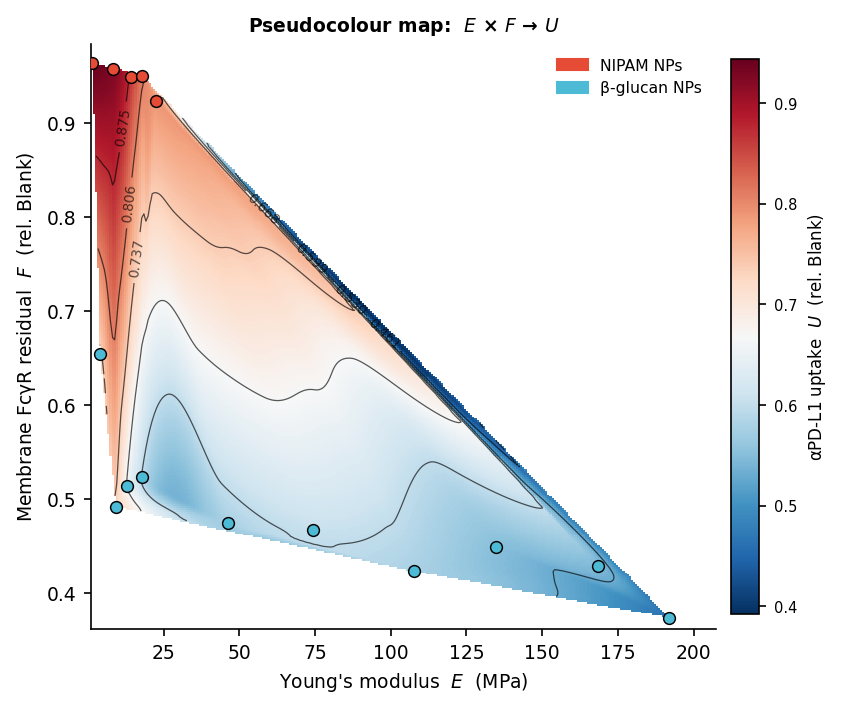

In [6]:
# ── Figure 1: Pseudocolour heatmap (E × F) → U ───────────────────────────────
gx  = np.linspace(E.min() * 0.85, E.max() * 1.08, 300)
gy  = np.linspace(F.min() * 0.97, F.max() * 1.02, 300)
GX, GY = np.meshgrid(gx, gy)
GZ  = griddata((E, F), U, (GX, GY), method='cubic')
GZ  = np.ma.array(GZ, mask=np.isnan(GZ))
vmin, vmax = float(np.nanmin(GZ)), float(np.nanmax(GZ))

fig, ax = plt.subplots(figsize=(5.8, 4.8))
pc = ax.pcolormesh(GX, GY, GZ, shading='auto',
                   cmap='RdBu_r', vmin=vmin, vmax=vmax)
cs = ax.contour(GX, GY, GZ,
                levels=np.linspace(vmin, vmax, 9),
                colors='k', linewidths=0.6, alpha=0.65)
ax.clabel(cs, inline=True, fontsize=6.5, fmt='%.3f')

for x, y, c_ in zip(E, F, col_pts):
    ax.scatter(x, y, s=32, color=c_, edgecolor='k',
               linewidths=0.7, zorder=5)

cb = plt.colorbar(pc, ax=ax, pad=0.02, shrink=0.95)
cb.set_label('αPD-L1 uptake  $U$  (rel. Blank)', fontsize=8)
cb.ax.tick_params(labelsize=7)
ax.set_xlabel("Young's modulus  $E$  (MPa)")
ax.set_ylabel('Membrane FcγR residual  $F$  (rel. Blank)')
ax.set_title('Pseudocolour map:  $E$ × $F$ → $U$')
ax.legend(
    handles=[
        mpatches.Patch(color=C_NIPAM, label='NIPAM NPs'),
        mpatches.Patch(color=C_BGLU,  label='β-glucan NPs'),
    ],
    loc='upper right', fontsize=7.5)
plt.tight_layout()
plt.show()

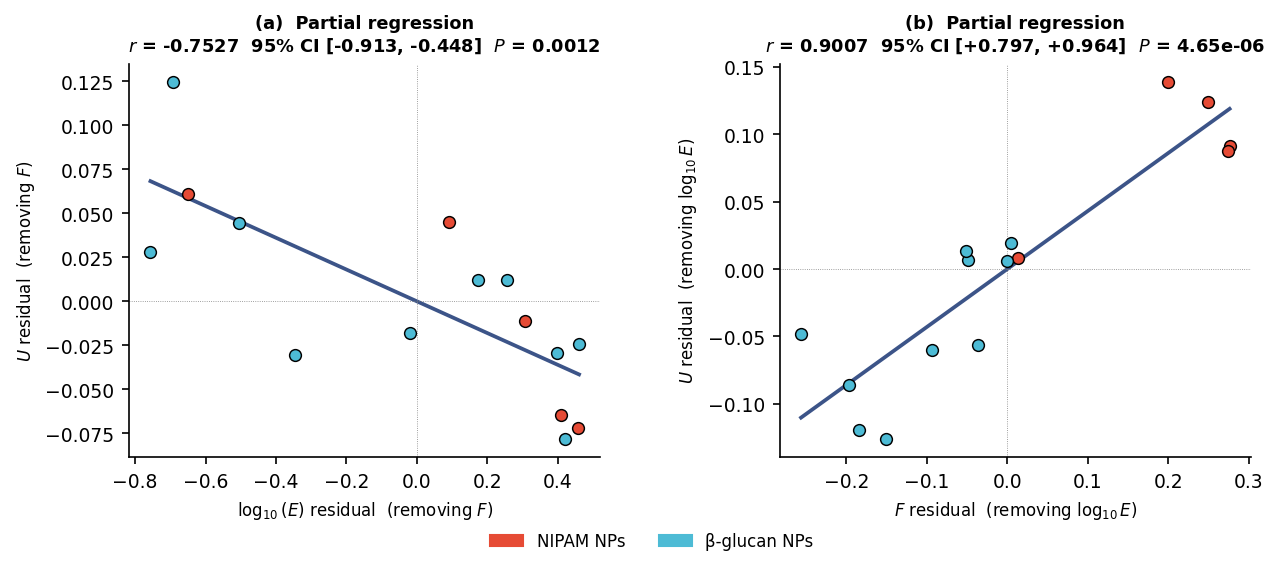

In [7]:
# ── Figure 2: Partial regression (added-variable) plots ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
plt.subplots_adjust(left=0.09, right=0.97,
                    bottom=0.19, top=0.88, wspace=0.38)

panels = [
    (axes[0],
     res_E_on_F, res_U_on_F,
     r'$\log_{10}(E)$ residual  (removing $F$)',
     r'$U$ residual  (removing $F$)',
     r_EU_givenF, p_EU_givenF, ci_rEU, 'a'),
    (axes[1],
     res_F_on_E, res_U_on_E,
     r'$F$ residual  (removing $\log_{10}E$)',
     r'$U$ residual  (removing $\log_{10}E$)',
     r_FU_givenE, p_FU_givenE, ci_rFU, 'b'),
]

for ax, rx, ry, xl, yl, rv, pv, ci_rv, tag in panels:
    for x, y, c_ in zip(rx, ry, col_pts):
        ax.scatter(x, y, color=c_, s=32, edgecolor='k',
                   linewidths=0.7, zorder=3)
    mf, bf = np.polyfit(rx, ry, 1)
    xx = np.linspace(rx.min(), rx.max(), 200)
    ax.plot(xx, mf * xx + bf, color=C_FIT, lw=1.8)
    ax.axhline(0, color='gray', lw=0.4, ls=':')
    ax.axvline(0, color='gray', lw=0.4, ls=':')
    ax.set_xlabel(xl, fontsize=8)
    ax.set_ylabel(yl, fontsize=8)
    ax.set_title(
        f'({tag})  Partial regression\n'
        f'$r$ = {rv:.4f}  '
        f'95% CI {ci3(ci_rv[0], ci_rv[1])}  '
        f'$P$ = {fmt_p(pv)}',
        fontsize=8.5)

fig.legend(
    handles=[
        mpatches.Patch(color=C_NIPAM, label='NIPAM NPs'),
        mpatches.Patch(color=C_BGLU,  label='β-glucan NPs'),
    ],
    loc='lower center', ncol=2,
    bbox_to_anchor=(0.5, 0.0), fontsize=8)
plt.show()

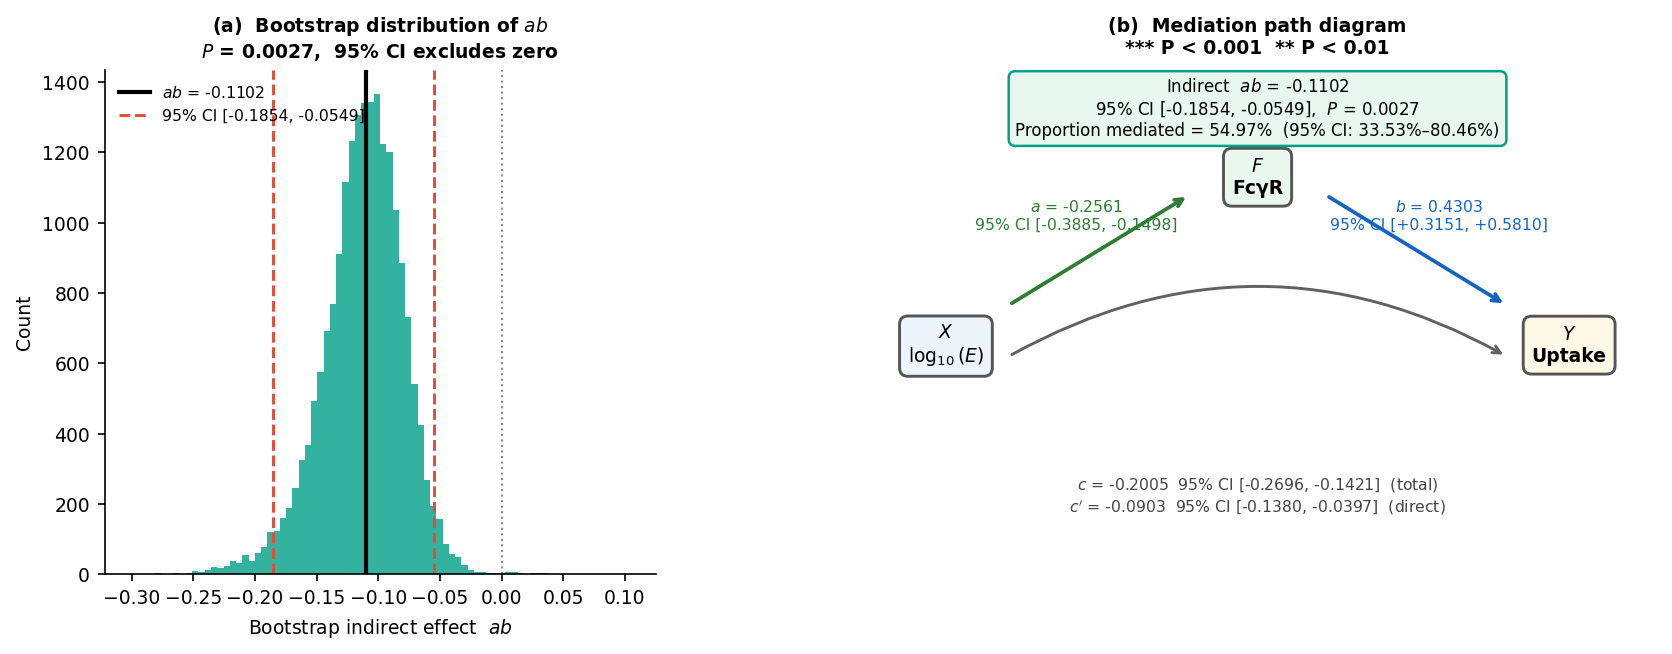

In [8]:
# ── Figure 3: Bootstrap distribution + mediation path diagram ────────────────
fig = plt.figure(figsize=(11.5, 4.6))
gs  = gridspec.GridSpec(
    1, 2, width_ratios=[1, 1.45],
    left=0.07, right=0.97, top=0.87, bottom=0.14, wspace=0.30)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# Panel (a): Bootstrap histogram of ab
ax0.hist(ab_arr, bins=80, color=C_ACCENT, edgecolor='none', alpha=0.80)
ax0.axvline(ab, color='k', lw=2.0,
            label=f'$ab$ = {ab:.4f}')
ax0.axvline(ci_ab[0], color=C_NIPAM, lw=1.4, ls='--',
            label=f'95% CI {ci4(ci_ab[0], ci_ab[1])}')
ax0.axvline(ci_ab[1], color=C_NIPAM, lw=1.4, ls='--')
ax0.axvline(0, color='#888', lw=1.0, ls=':')
ax0.set_xlabel('Bootstrap indirect effect  $ab$', fontsize=9)
ax0.set_ylabel('Count', fontsize=9)
ax0.set_title(
    f'(a)  Bootstrap distribution of $ab$\n'
    f'$P$ = {fmt_p(p_ab)},  95% CI excludes zero',
    fontsize=9)
ax0.legend(fontsize=7.5, loc='upper left')

# Panel (b): Path diagram
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6.6)
ax1.axis('off')

NODE = dict(boxstyle='round,pad=0.45', linewidth=1.4)
for lbl, (x, y), fc in [
    ('$X$\n$\\log_{10}(E)$', (1.1, 3.0), '#EBF5FB'),
    ('$F$\nFcγR',            (5.0, 5.2), '#EAF7EE'),
    ('$Y$\nUptake',          (8.9, 3.0), '#FEF9E7'),
]:
    ax1.text(x, y, lbl, ha='center', va='center',
             fontsize=9, fontweight='bold',
             bbox=dict(**NODE, facecolor=fc, edgecolor='#555'))

ax1.annotate('', xy=(4.15, 4.97), xytext=(1.88, 3.52),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='#2E7D32'))
ax1.text(2.73, 4.52,
         f'$a$ = {a:.4f}\n95% CI {ci4(ci_a[0], ci_a[1])}',
         color='#2E7D32', fontsize=7.5, ha='center')

ax1.annotate('', xy=(8.12, 3.52), xytext=(5.85, 4.97),
             arrowprops=dict(arrowstyle='->', lw=1.8, color='#1565C0'))
ax1.text(7.27, 4.52,
         f'$b$ = {b:.4f}\n95% CI {ci4(ci_b[0], ci_b[1])}',
         color='#1565C0', fontsize=7.5, ha='center')

ax1.annotate('', xy=(8.12, 2.85), xytext=(1.88, 2.85),
             arrowprops=dict(
                 arrowstyle='->', lw=1.4, color='#616161',
                 connectionstyle='arc3,rad=-0.28'))
ax1.text(
    5.0, 0.82,
    f'$c$ = {c_total:.4f}  95% CI {ci4(ci_c[0], ci_c[1])}  (total)\n'
    f"$c'$ = {c_prime:.4f}  95% CI {ci4(ci_cp[0], ci_cp[1])}  (direct)",
    ha='center', fontsize=7.5, color='#444')

ax1.text(
    5.0, 6.10,
    f'Indirect  $ab$ = {ab:.4f}\n'
    f'95% CI {ci4(ci_ab[0], ci_ab[1])},  $P$ = {fmt_p(p_ab)}\n'
    f'Proportion mediated = {prop * 100:.2f}%  '
    f'(95% CI: {ci_pr[0] * 100:.2f}%–{ci_pr[1] * 100:.2f}%)',
    ha='center', va='center', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#E8F8EF', edgecolor=C_ACCENT, lw=1.2))

ax1.set_title(
    '(b)  Mediation path diagram\n*** P < 0.001  ** P < 0.01',
    fontsize=9, pad=8)
plt.show()

---
## §6 — Consolidated Parameter Report

All estimates to 4 decimal places. P-values: 4 d.p. if ≥ 0.0001, scientific notation if < 0.0001.

In [9]:
SEP = '=' * 70
print(SEP)
print('SMART STATISTICAL ANALYSIS — CONSOLIDATED PARAMETER REPORT')
print(f'Dataset: n = {n} pooled conditions  '
      f'(NIPAM NPs: 5, β-glucan NPs: 10)')
print(f'Bootstrap: B = {B_ALL:,}, seed = {SEED}, paired percentile resampling')
print(SEP)

print('\n── SPEARMAN RANK CORRELATIONS ──────────────────────────────────────')
rhoEU = spearman_store['E vs U']['rho']
rhoEF = spearman_store['E vs F']['rho']
rhoFU = spearman_store['F vs U']['rho']
ciEU  = spearman_store['E vs U']['ci']
ciEF  = spearman_store['E vs F']['ci']
ciFU  = spearman_store['F vs U']['ci']
pEU   = spearman_store['E vs U']['p']
pEF   = spearman_store['E vs F']['p']
pFU   = spearman_store['F vs U']['p']
print(f'  ρ(E, U)  = {rhoEU:+.4f}   95% CI {ci3(ciEU[0], ciEU[1])}   P = {fmt_p(pEU)}')
print(f'  ρ(E, F)  = {rhoEF:+.4f}   95% CI {ci3(ciEF[0], ciEF[1])}   P = {fmt_p(pEF)}')
print(f'  ρ(F, U)  = {rhoFU:+.4f}   95% CI {ci3(ciFU[0], ciFU[1])}   P = {fmt_p(pFU)}')

print('\n── PARTIAL CORRELATIONS ────────────────────────────────────────────')
print(f'  r(F→U | log₁₀E) = {r_FU_givenE:+.4f}   '
      f'95% CI {ci3(ci_rFU[0], ci_rFU[1])}   '
      f'P = {fmt_p(p_FU_givenE)}')
print(f'  r(E→U | F)       = {r_EU_givenF:+.4f}   '
      f'95% CI {ci3(ci_rEU[0], ci_rEU[1])}   '
      f'P = {fmt_p(p_EU_givenF)}')

print('\n── VARIANCE DECOMPOSITION (semi-partial R²) ────────────────────────')
print(f'  R²(E alone)          = {R2_E:.4f}')
print(f'  R²(F alone)          = {R2_F:.4f}')
print(f'  R²(E + F, joint)     = {R2_joint:.4f}')
print(f'  Unique to F          = {semi_F:.4f}  '
      f'({semi_F / R2_joint * 100:.1f}%)   '
      f'95% CI [{ci_sF[0]:.4f}, {ci_sF[1]:.4f}]')
print(f'  Unique to E          = {semi_E:.4f}  '
      f'({semi_E / R2_joint * 100:.1f}%)   '
      f'95% CI [{ci_sE[0]:.4f}, {ci_sE[1]:.4f}]')
print(f'  Shared (collinearity)= {shared:.4f}  '
      f'({shared / R2_joint * 100:.1f}%)   '
      f'95% CI [{ci_sh[0]:.4f}, {ci_sh[1]:.4f}]')

print('\n── STANDARDISED REGRESSION COEFFICIENTS ───────────────────────────')
print(f'  β_log₁₀E  = {beta_E:+.4f}   95% CI {ci3(ci_bE[0], ci_bE[1])}')
print(f'  β_F        = {beta_F:+.4f}   95% CI {ci3(ci_bF[0], ci_bF[1])}')
print(f'  |β_F| / |β_E| = {abs(beta_F) / abs(beta_E):.4f}×')

print('\n── BOOTSTRAP MEDIATION ANALYSIS ────────────────────────────────────')
print(f'  Path a   (log₁₀E → F)    = {a:+.4f}   '
      f'95% CI {ci4(ci_a[0], ci_a[1])}')
print(f'  Path b   (F → U | log₁₀E)= {b:+.4f}   '
      f'95% CI {ci4(ci_b[0], ci_b[1])}')
print(f'  Total effect  c           = {c_total:+.4f}   '
      f'95% CI {ci4(ci_c[0], ci_c[1])}')
print(f"  Direct effect  c'         = {c_prime:+.4f}   "
      f'95% CI {ci4(ci_cp[0], ci_cp[1])}')
print(f'  Indirect effect  ab       = {ab:+.4f}   '
      f'95% CI {ci4(ci_ab[0], ci_ab[1])}   '
      f'P = {fmt_p(p_ab)}')
print(f'  Proportion mediated ab/c  = {prop * 100:.4f}%   '
      f'95% CI [{ci_pr[0] * 100:.4f}%, {ci_pr[1] * 100:.4f}%]')
print(f'  Mediation confirmed (CI excludes zero): '
      f'{"YES" if ci_ab[0] * ci_ab[1] > 0 else "NO"}')

print('\n── INTERPRETATION ──────────────────────────────────────────────────')
print(f'  All three frameworks converge: F is the dominant mediator.')
print(f'  F unique R² ({semi_F / R2_joint * 100:.1f}%) is '
      f'{semi_F / semi_E:.1f}× that of E ({semi_E / R2_joint * 100:.1f}%).')
print(f'  {prop * 100:.2f}% of total stiffness–uptake effect '
      f'is transmitted through FcγR redistribution.')
print(SEP)

SMART STATISTICAL ANALYSIS — CONSOLIDATED PARAMETER REPORT
Dataset: n = 15 pooled conditions  (NIPAM NPs: 5, β-glucan NPs: 10)
Bootstrap: B = 20,000, seed = 2025, paired percentile resampling

── SPEARMAN RANK CORRELATIONS ──────────────────────────────────────
  ρ(E, U)  = -0.8536   95% CI [-0.989, -0.515]   P = 5.17e-05
  ρ(E, F)  = -0.8321   95% CI [-0.975, -0.461]   P = 0.0001
  ρ(F, U)  = +0.9429   95% CI [+0.764, +0.996]   P = 1.42e-07

── PARTIAL CORRELATIONS ────────────────────────────────────────────
  r(F→U | log₁₀E) = +0.9007   95% CI [+0.797, +0.964]   P = 4.65e-06
  r(E→U | F)       = -0.7527   95% CI [-0.913, -0.448]   P = 0.0012

── VARIANCE DECOMPOSITION (semi-partial R²) ────────────────────────
  R²(E alone)          = 0.6897
  R²(F alone)          = 0.8649
  R²(E + F, joint)     = 0.9415
  Unique to F          = 0.2517  (26.7%)   95% CI [0.0892, 0.5081]
  Unique to E          = 0.0765  (8.1%)   95% CI [0.0095, 0.2058]
  Shared (collinearity)= 0.6132  (65.1%)   95% C